<a href="https://colab.research.google.com/github/nastya-kolle/mathematical-computational-modeling/blob/main/MCM_12_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №12. Преобразование Фурье для решения ОДУ

**Задача.** Решить линейное ОДУ второго порядка с помощью преобразования Фурье:

`y'' - 2*y' + y = 1/(1 + x²)`, `x ∈ ℝ`.

Нужно применить преобразование Фурье к обеим частям уравнения, найти образ Фурье
решения, построить функцию Грина как обратное преобразование Фурье от `1/L(iξ)`
(где `L` — характеристический полином оператора) и получить решение в виде свёртки
правой части с функцией Грина.


Решение ОДУ: y''(x) - 2y'(x) + y(x) = 1/(1+x²)
───────────────────────────────────────────────────────
  Максимум |y(x)| на [-10,10]          : 0.601391
  Максимальная невязка на [-10,10]      : 3.00e-05
  Макс. расхождение FFT vs свёртка      : 2.26e-05

Функция Грина: g(x) = −x·eˣ·H(−x)
Решение: y(x) = ∫_x^∞ (t−x)·e^(x−t) / (1+t²) dt


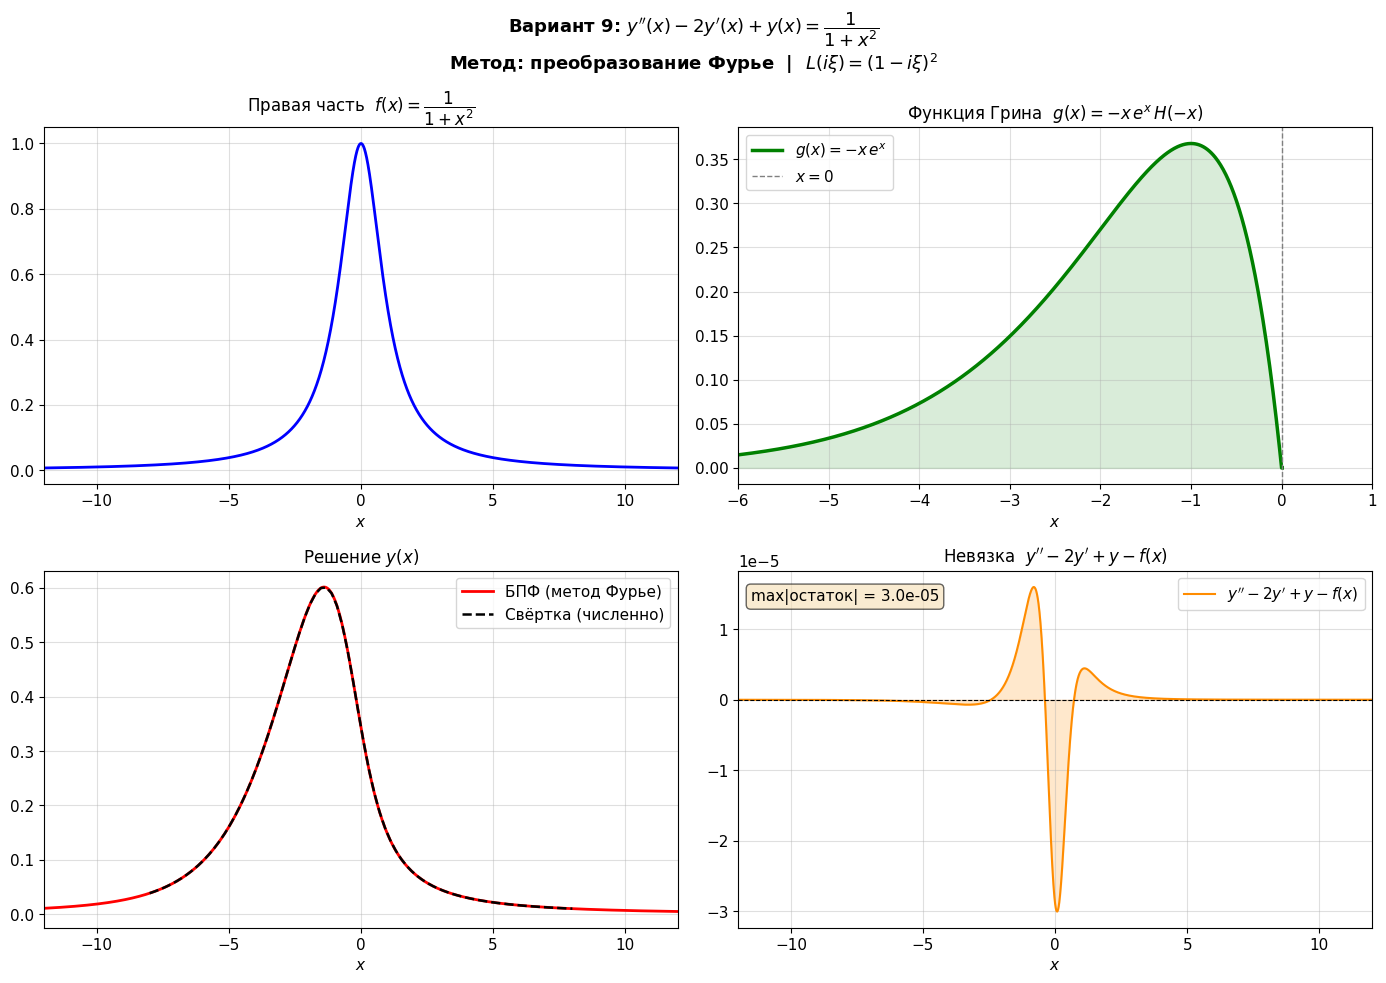

In [ ]:
"""
=======================================================================
Лабораторная работа №12 — Вариант 9
Применение преобразования Фурье к решению ОДУ

Уравнение:  y''(x) - 2y'(x) + y(x) = 1/(1+x²),  x ∈ ℝ

Аналитический ход решения:
─────────────────────────────────────────────────────────────────────
1) Применяем ПФ к обеим частям:
      F[y''](ξ) = (iξ)²·ŷ = -ξ²·ŷ
      F[y' ](ξ) = iξ·ŷ
   Получаем:  (-ξ² - 2iξ + 1)·ŷ(ξ) = f̂(ξ)

2) Характеристический полином:
      L(iξ) = (iξ)² - 2(iξ) + 1 = (1 - iξ)²
   (корни L(r)=0:  r=1 — двукратный; на вещественной оси нулей нет ⟹
    деление допустимо)

3) Образ Фурье решения:
      ŷ(ξ) = f̂(ξ) / (1 - iξ)²

4) Функция Грина (обратное ПФ от 1/L(iξ)):
      F[eˣ H(-x)](ξ) = 1/(1-iξ)         (прямая проверка)
      F[x·eˣ H(-x)](ξ) = -1/(1-iξ)²     (свойство xf(x) ↔ i·d/dξ F[f])
   ⟹  g(x) = F⁻¹[1/(1-iξ)²] = -x·eˣ·H(-x)

5) Решение через свёртку (теорема о свёртке):
      y(x) = (f * g)(x)
           = ∫_{-∞}^{+∞} f(t)·g(x-t) dt
           = ∫_{x}^{+∞} f(t)·(t-x)·e^{x-t} dt       [g(s)≠0 при s<0]
=======================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq

plt.rcParams.update({'font.size': 11})


# ═══════════════════════════════════════════════════════════════════
# 1. Вспомогательные функции
# ═══════════════════════════════════════════════════════════════════

def right_side(x):
    """Правая часть ОДУ: f(x) = 1/(1+x²)."""
    return 1.0 / (1.0 + x**2)


def green_function(x):
    """
    Функция Грина оператора L(d/dx) = d²/dx² - 2d/dx + 1.
    g(x) = -x·eˣ·H(-x)
    """
    return np.where(x < 0, -x * np.exp(x), 0.0)


def solve_via_fft(x_max=60.0, N=2**14):
    """
    Решение ОДУ методом БПФ.

    Нормировка преобразования Фурье, используемая в задаче:
        f̂(ξ) = ∫ f(x) e^{-ixξ} dx
        f(x)  = (1/2π) ∫ f̂(ξ) e^{iξx} dξ

    Перевод в дискретный случай (x[n] = n·dx - x_max):
        f̂(ξ_k) = dx · exp(i·x_max·ξ_k) · FFT(f)[k]
        y[n]    = (1/dx) · Re{ IFFT( Ŷ[k] · exp(-i·x_max·ξ_k) ) }[n]
    """
    dx = 2.0 * x_max / N
    x  = np.arange(N) * dx - x_max        # сетка по x
    xi = fftfreq(N, d=dx) * 2.0 * np.pi  # угловые частоты

    f = right_side(x)

    # Прямое ПФ
    F_hat = dx * np.exp(1j * x_max * xi) * fft(f)

    # Характеристический полином L(iξ) = (1 - iξ)²
    L_poly = (1.0 - 1j * xi) ** 2

    # Образ решения
    Y_hat = F_hat / L_poly

    # Обратное ПФ
    y = np.real(ifft(Y_hat * np.exp(-1j * x_max * xi))) / dx

    return x, y, f


def solve_via_convolution(x_grid, x_vals):
    """
    Решение через интеграл свёртки (численное):
        y(x₀) = ∫_{x₀}^{+∞} (t - x₀)·e^{x₀-t}·f(t) dt
    Используется для проверки метода БПФ.
    """
    result = np.empty(len(x_vals))
    f_vals = right_side(x_grid)
    for i, x0 in enumerate(x_vals):
        mask      = x_grid >= x0
        t         = x_grid[mask]
        integrand = (t - x0) * np.exp(-(t - x0)) * f_vals[mask]
        result[i] = np.trapezoid(integrand, t)
    return result


def numerical_residual(x, y, dx):
    """
    Проверка: вычислить y'' - 2y' + y - f(x) конечными разностями.
    """
    dy  = np.gradient(y, dx)
    d2y = np.gradient(dy, dx)
    return d2y - 2.0 * dy + y - right_side(x)


# ═══════════════════════════════════════════════════════════════════
# 2. Основные вычисления
# ═══════════════════════════════════════════════════════════════════

print("Решение ОДУ: y''(x) - 2y'(x) + y(x) = 1/(1+x²)")
print("─" * 55)

# Решение методом БПФ
x_full, y_fft, f_full = solve_via_fft(x_max=60.0, N=2**14)
dx = x_full[1] - x_full[0]

# Невязка
residual = numerical_residual(x_full, y_fft, dx)

# Решение через свёртку на контрольных точках
x_check  = np.linspace(-8, 8, 80)
y_check  = solve_via_convolution(x_full, x_check)

# Функция Грина
g_full   = green_function(x_full)

# Маски для области отображения
mask_main = (-12 <= x_full) & (x_full <= 12)
mask_g    = (-6  <= x_full) & (x_full < 0.01)

# ═══════════════════════════════════════════════════════════════════
# 3. Статистика
# ═══════════════════════════════════════════════════════════════════

inner = (-10 <= x_full) & (x_full <= 10)
max_res   = np.max(np.abs(residual[inner]))
max_y_fft = np.max(np.abs(y_fft[inner]))

# Сравнение FFT и свёртки
y_fft_at_check = np.interp(x_check, x_full, y_fft)
max_diff = np.max(np.abs(y_fft_at_check - y_check))

print(f"  Максимум |y(x)| на [-10,10]          : {max_y_fft:.6f}")
print(f"  Максимальная невязка на [-10,10]      : {max_res:.2e}")
print(f"  Макс. расхождение FFT vs свёртка      : {max_diff:.2e}")
print()
print("Функция Грина: g(x) = −x·eˣ·H(−x)")
print("Решение: y(x) = ∫_x^∞ (t−x)·e^(x−t) / (1+t²) dt")


# ═══════════════════════════════════════════════════════════════════
# 4. Графики
# ═══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    r"Вариант 9: $y''(x) - 2y'(x) + y(x) = \dfrac{1}{1+x^2}$"
    "\n"
    r"Метод: преобразование Фурье  |  $L(i\xi)=(1-i\xi)^2$",
    fontsize=13, fontweight='bold'
)

# ── (a) Правая часть ─────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(x_full[mask_main], f_full[mask_main], 'b-', lw=2)
ax.set_title(r'Правая часть  $f(x)=\dfrac{1}{1+x^2}$', fontsize=12)
ax.set_xlabel('$x$')
ax.set_xlim(-12, 12); ax.grid(True, alpha=0.4)

# ── (b) Функция Грина ────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(x_full[mask_g], g_full[mask_g], 'g-', lw=2.5,
        label=r'$g(x) = -x\,e^x$')
ax.axvline(0, color='gray', ls='--', lw=1, label='$x=0$')
ax.fill_between(x_full[mask_g], g_full[mask_g], alpha=0.15, color='g')
ax.set_title(r'Функция Грина  $g(x) = -x\,e^x\, H(-x)$', fontsize=12)
ax.set_xlabel('$x$')
ax.set_xlim(-6, 1); ax.legend(); ax.grid(True, alpha=0.4)

# ── (c) Решение ──────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(x_full[mask_main], y_fft[mask_main],
        'r-', lw=2, label='БПФ (метод Фурье)')
ax.plot(x_check, y_check,
        'k--', lw=1.8, label='Свёртка (численно)')
ax.set_title(r'Решение $y(x)$', fontsize=12)
ax.set_xlabel('$x$')
ax.set_xlim(-12, 12)
ax.legend(); ax.grid(True, alpha=0.4)

# ── (d) Невязка ──────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(x_full[mask_main], residual[mask_main],
        color='darkorange', lw=1.5, label=r"$y''-2y'+y - f(x)$")
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.fill_between(x_full[mask_main], residual[mask_main],
                alpha=0.2, color='darkorange')
ax.set_title(r"Невязка  $y''-2y'+y - f(x)$", fontsize=12)
ax.set_xlabel('$x$')
ax.set_xlim(-12, 12)
ax.legend(); ax.grid(True, alpha=0.4)
ax.text(0.02, 0.95, f'max|остаток| = {max_res:.1e}',
        transform=ax.transAxes, va='top',
        bbox=dict(boxstyle='round', fc='wheat', alpha=0.6))

plt.tight_layout()
plt.show()
